# OSM roads — Milan

Loads the enriched acoustic classification (zones with legal dB limits), downloads the
OSM drive network for Milan, assigns each street segment to its acoustic zone via the
segment midpoint, classifies the dB limits into the 5 noise classes used by the ML
pipeline, computes distance-to-road-category features and exports
`../layers/MIL_noise_streets.gpkg` and `data/osm_roads_noise_class.csv`.

In [1]:
import os
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import and analyse the acoustic zoning dataset

In [2]:
_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
acoustic = gpd.read_file(os.path.join(_layers_dir, 'milan_acoustic_classification_enriched.geojson'))
acoustic = acoustic.to_crs('EPSG:32632')
acoustic['CLASSE_ACU'] = acoustic['CLASSE_ACU'].astype(int)
print('CRS:', acoustic.crs)
print('Shape:', acoustic.shape)
print(acoustic['CLASSE_ACU'].value_counts().sort_index())

C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


CRS: EPSG:32632
Shape: (8828, 9)
CLASSE_ACU
1      13
2     421
3    2397
4    5781
5     215
6       1
Name: count, dtype: int64


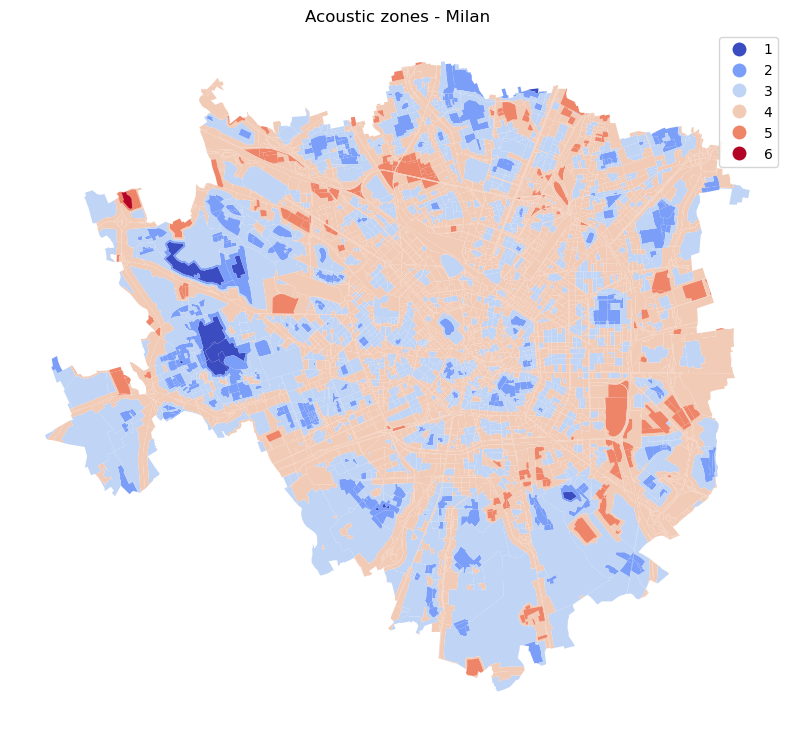

In [3]:
ax = acoustic.plot(column='CLASSE_ACU', cmap='coolwarm', categorical=True,
                   legend=True, figsize=(10, 10), linewidth=0)
ax.set_title('Acoustic zones - Milan')
ax.set_axis_off()

## Roads - OSM

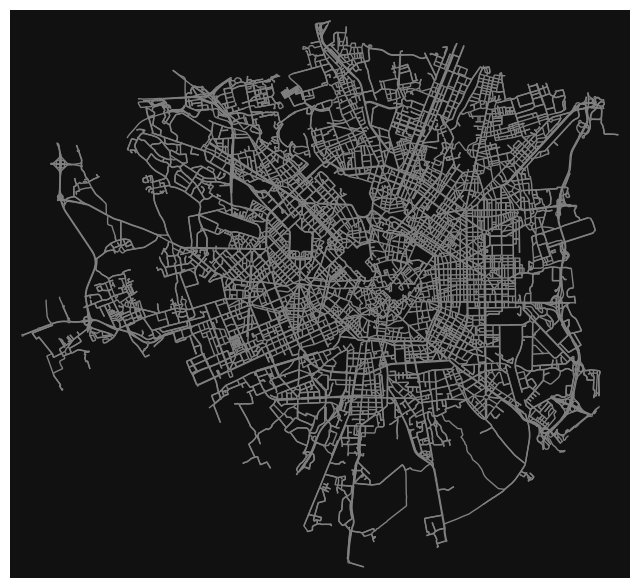

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
GRAPHML_PATH = os.path.join('data', 'milan.graphml')
os.makedirs('data', exist_ok=True)

if os.path.exists(GRAPHML_PATH):
    print('Loading cached graph from', GRAPHML_PATH)
    G = ox.load_graphml(GRAPHML_PATH)
else:
    print('Downloading Milan OSM graph (drive network) ...')
    G = ox.graph_from_place('Milan, Italy', network_type='drive')
    ox.save_graphml(G, GRAPHML_PATH)

ox.plot_graph(G, edge_color='gray', node_size=0)

## Prepare graph edges (roads)

In [5]:
nodes, edges = ox.graph_to_gdfs(G)

# Assign a unique segment_id to each edge based on its start and end nodes and its key
edges["segment_id"] = edges.index.map(lambda x: f"{x[0]}_{x[1]}_{x[2]}")
edges['segment_id'].head(10)

# Project edges to the same CRS as the acoustic zones (EPSG:32632 — WGS84 / UTM 32N)
roads = edges[edges.geometry.type == 'LineString'].to_crs(acoustic.crs)
print('Roads:', len(roads), 'CRS:', roads.crs)

Roads: 25452 CRS: EPSG:32632


## Check features completeness

In [6]:
for col in ['width', 'maxspeed', 'lanes', 'oneway']:
    if col in roads.columns:
        print(f'Checking {col}..')
        print(roads[col].value_counts(dropna=False).head(20))
    else:
        print(f'{col}: column not present')

Checking width..
width
NaN         25109
6              52
8              50
5              37
3              30
7              21
9              18
4              17
10             12
7.5             8
14              7
15              6
5.5             6
4.4             6
4.5             5
11              5
8.5             4
[5, 4.5]        4
3.5             4
6.8             3
Name: count, dtype: int64
Checking maxspeed..
maxspeed
NaN         15882
50           4915
30           4089
40            199
70             95
15             67
90             60
[30, 50]       52
10             17
80             16
20              7
60              7
[80, 90]        5
[15, 30]        5
[70, 50]        5
IT:urban        4
100             4
[90, 40]        2
[10, 50]        2
[70, 90]        2
Name: count, dtype: int64
Checking lanes..
lanes
NaN          16462
2             5404
1             2944
3              308
4              159
[2, 1]          70
[2, 3]          61
[4, 3]          17
5

## Check if road is tunnel

In [7]:
# OSM 'tunnel' values can be strings or lists — mark as tunnel if any value is 'yes'
if 'tunnel' in roads.columns:
    roads['is_tunnel'] = roads['tunnel'].apply(
        lambda v: 1 if v == 'yes' or (isinstance(v, list) and 'yes' in v) else 0
    )
else:
    roads['is_tunnel'] = 0

print(roads['is_tunnel'].value_counts())

is_tunnel
0    25307
1      145
Name: count, dtype: int64


## Filter roads categories

In [8]:
# Filter to only primary and secondary roads
categories = ['living_street','residential','primary','secondary','tertiary','trunk']
roads_filtered = roads[roads['highway'].isin(categories)&
    (roads['is_tunnel'] == 0)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")

Original: 25452, Filtered: 22164


## Plot road categories distribution

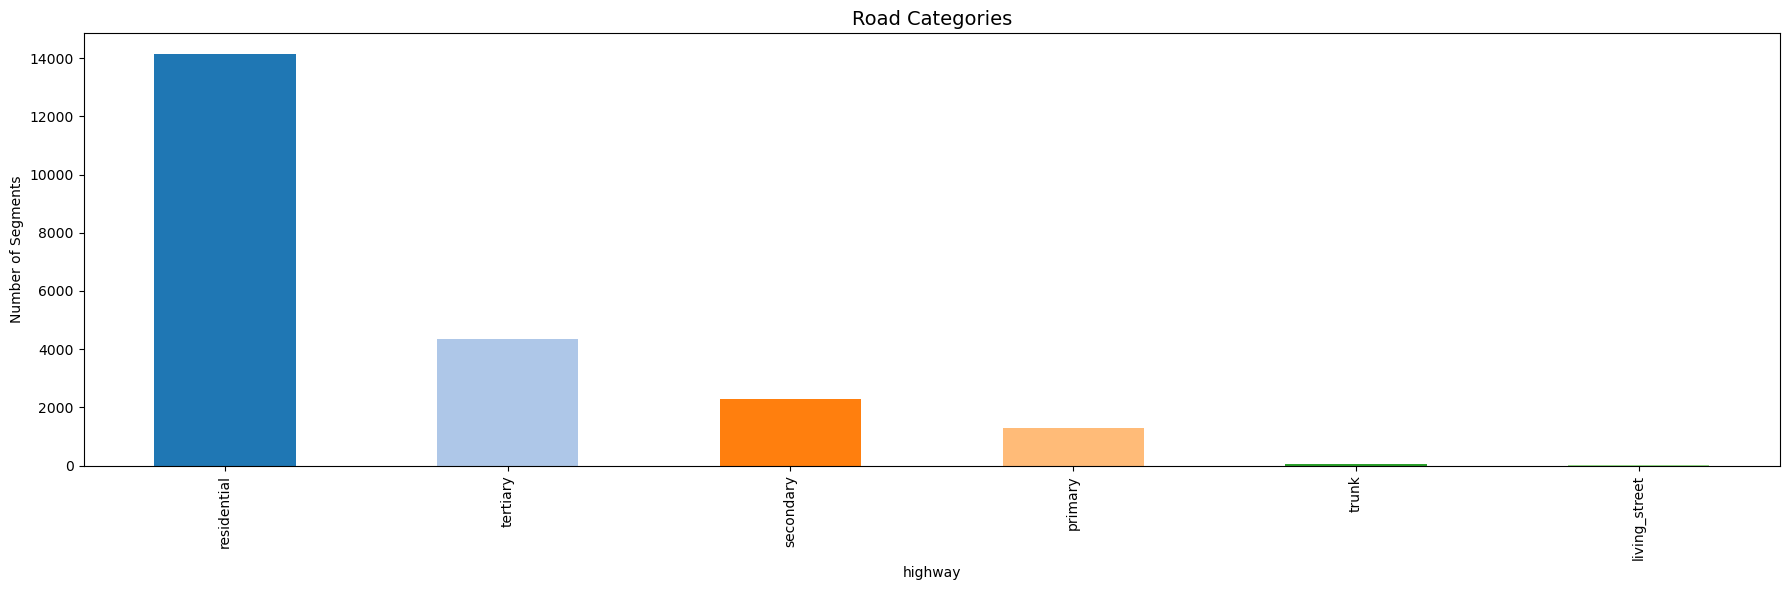

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

class_count = roads_filtered['highway'].value_counts()

class_count.plot(kind='bar', ax=axes, color=plt.cm.tab20.colors[:len(class_count)])
axes.set_title("Road Categories", fontsize=14)
axes.set_ylabel("Number of Segments")
axes.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

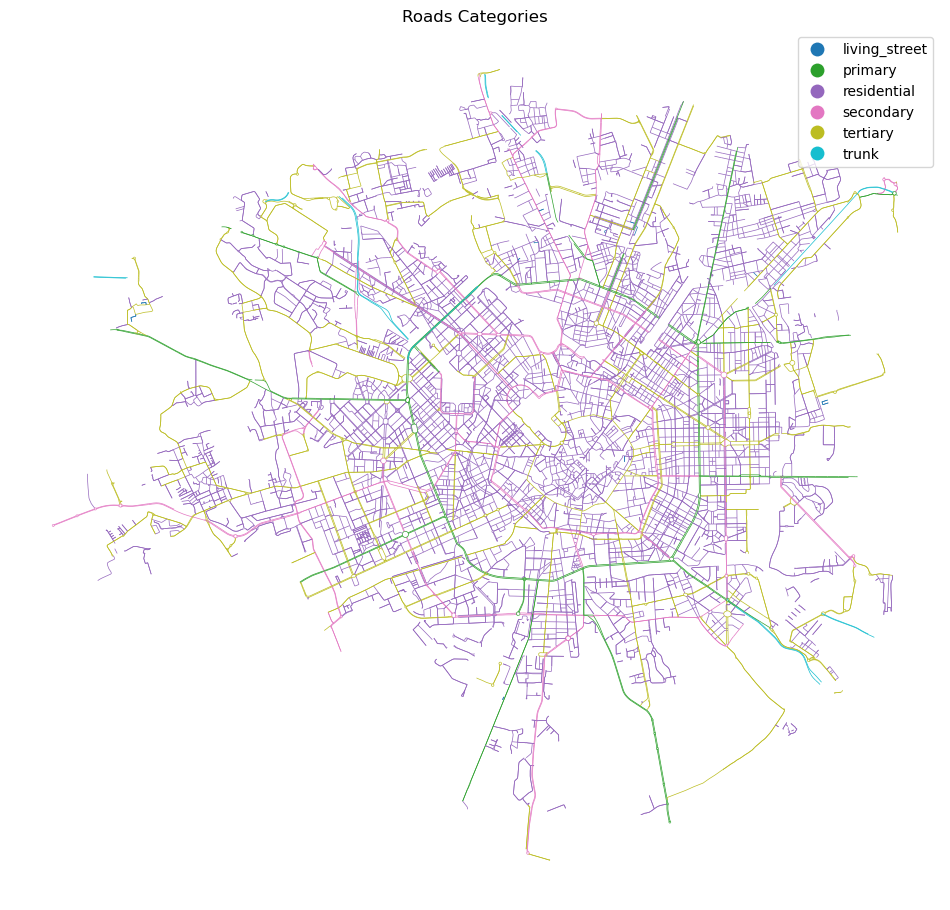

In [10]:
ax = roads_filtered.plot(column='highway', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Roads Categories')
ax.set_axis_off()

## Assign acoustic zone to each street segment

Each segment inherits `CLASSE_ACU`, `db_diurno` and `db_notturno` from the acoustic
zone containing its midpoint. Segments whose midpoint falls outside the zoning
(e.g. on the municipal boundary) get the nearest zone, with the distance recorded.

In [11]:
# Step 1: midpoint-within join
noise_roads = roads_filtered.reset_index(drop=True).copy()
midpoints = noise_roads[['segment_id']].copy()
midpoints = gpd.GeoDataFrame(midpoints,
                             geometry=noise_roads.geometry.interpolate(0.5, normalized=True),
                             crs=noise_roads.crs)

zone_cols = ['CLASSE_ACU', 'db_diurno', 'db_notturno']
joined = gpd.sjoin(midpoints, acoustic[zone_cols + ['geometry']],
                   how='left', predicate='within')
# A midpoint exactly on a zone boundary can match twice - keep the first match
joined = joined[~joined.index.duplicated(keep='first')]

for c in zone_cols:
    noise_roads[c] = joined[c]
noise_roads['distance'] = 0.0

matched = noise_roads['CLASSE_ACU'].notna().sum()
print(f'Matched by midpoint-within: {matched} / {len(noise_roads)}')

# Step 2: nearest-zone fallback for unmatched segments
unmatched = noise_roads['CLASSE_ACU'].isna()
if unmatched.any():
    um = midpoints.loc[unmatched]
    near = gpd.sjoin_nearest(um, acoustic[zone_cols + ['geometry']],
                             how='left', distance_col='dist_to_zone')
    near = near[~near.index.duplicated(keep='first')]
    for c in zone_cols:
        noise_roads.loc[unmatched, c] = near[c]
    noise_roads.loc[unmatched, 'distance'] = near['dist_to_zone']
    print(f'Nearest-zone fallback applied to {unmatched.sum()} segments '
          f'(max distance {near["dist_to_zone"].max():.0f} m)')

noise_roads = noise_roads[noise_roads['CLASSE_ACU'].notna()].copy()
noise_roads['CLASSE_ACU'] = noise_roads['CLASSE_ACU'].astype(int)
print(f'Final segments with acoustic zone: {len(noise_roads)}')
noise_roads[zone_cols + ['distance']].describe()

Matched by midpoint-within: 22146 / 22164
Nearest-zone fallback applied to 18 segments (max distance 12 m)
Final segments with acoustic zone: 22164


,CLASSE_ACU,db_diurno,db_notturno,distance
count,22164.000000,22164.000000,22164.000000,22164.000000
mean,3.623082,63.115412,53.115412,0.002768
std,0.594506,2.972530,2.972530,0.135723
min,2.000000,55.000000,45.000000,0.000000
25%,3.000000,60.000000,50.000000,0.000000
50%,4.000000,65.000000,55.000000,0.000000
75%,4.000000,65.000000,55.000000,0.000000
max,5.000000,70.000000,60.000000,11.935871


## Classify noise into 5 classes: <40, 40-50, 50-60, 60-70, >70

In [12]:
# Classify numeric noise dB into 5 classes: 0=<40, 1=40-50, 2=50-60, 3=60-70, 4=>70

def classify_noise(val):
    if val < 40:
        return 0
    elif val < 50:
        return 1
    elif val < 60:
        return 2
    elif val < 70:
        return 3
    else:
        return 4

print(classify_noise(72.3))  # expected: 4

4


In [13]:
# Milan law defines only diurnal (06-22) and nocturnal (22-06) periods —
# evening is set equal to day, as done for Berlin (Lden/Lnight only)
noise_roads['noise_day'] = noise_roads['db_diurno'].apply(classify_noise)
noise_roads['noise_evening'] = noise_roads['noise_day']
noise_roads['noise_night'] = noise_roads['db_notturno'].apply(classify_noise)

noise_roads.head()

,osmid,highway,lanes,name,oneway,reversed,length,geometry,maxspeed,junction,...,est_width,segment_id,is_tunnel,CLASSE_ACU,db_diurno,db_notturno,distance,noise_day,noise_evening,noise_night
0,274433644,primary,2,Via Novara,True,False,154.435012,"LINESTRING (505987.753 5037117.669, 505836.365...",NaN,NaN,...,NaN,10371529_743371634_0,0,4,65.0,55.0,0.0,3,3,2
1,26703159,tertiary,NaN,Via Novara,True,False,150.466270,"LINESTRING (505987.753 5037117.669, 505947.376...",NaN,NaN,...,NaN,10371529_743371622_0,0,4,65.0,55.0,0.0,3,3,2
2,"[270440428, 270390234, 270439972, 270390223]",primary,2,Via Novara,True,False,1075.839734,"LINESTRING (507976.056 5036258.912, 507948.227...",70,NaN,...,NaN,10371530_267873043_0,0,4,65.0,55.0,0.0,3,3,2
3,195654896,secondary,2,Viale Certosa,False,False,41.927380,"LINESTRING (510208.477 5038452.225, 510173.072...",50,NaN,...,NaN,13595397_271096577_0,0,4,65.0,55.0,0.0,3,3,2
4,195654901,secondary,NaN,Viale Certosa,True,False,16.212785,"LINESTRING (510208.477 5038452.225, 510208.318...",NaN,NaN,...,NaN,13595397_344814479_0,0,4,65.0,55.0,0.0,3,3,2


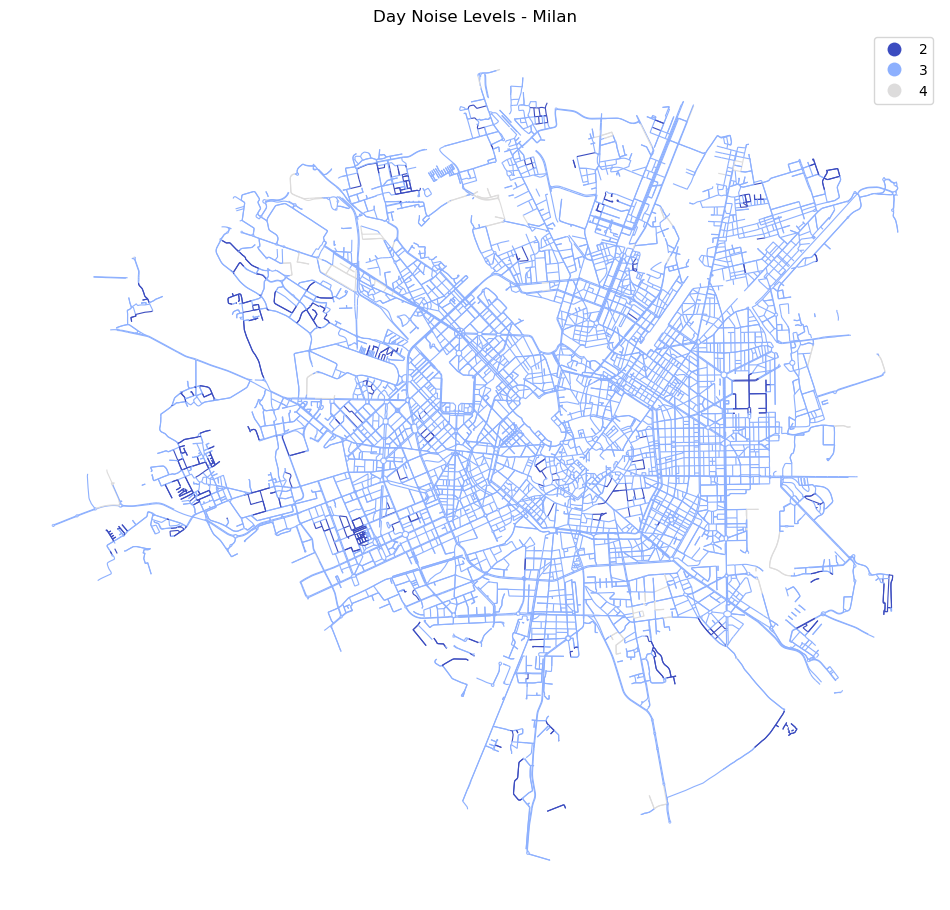

In [14]:
noise_roads['noise_day'] = noise_roads["noise_day"].astype("category")
ax = noise_roads.plot(cmap="coolwarm", column='noise_day', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Day Noise Levels - Milan')
ax.set_axis_off()

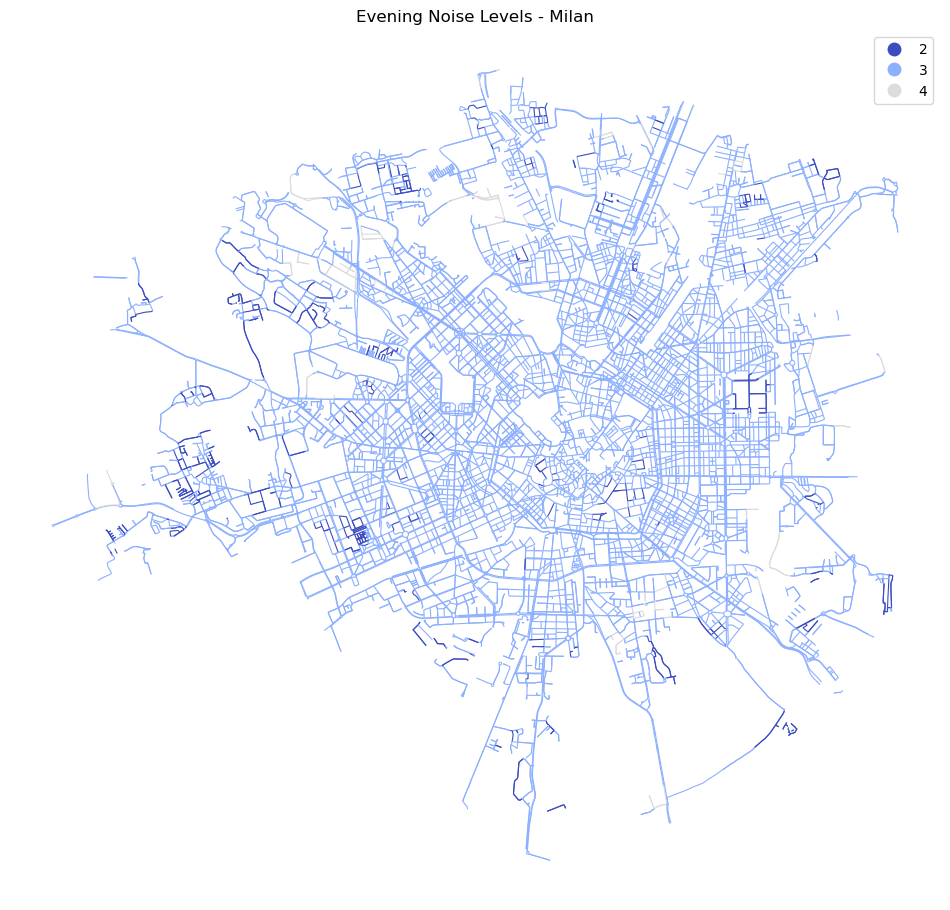

In [15]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_evening', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Evening Noise Levels - Milan')
ax.set_axis_off()

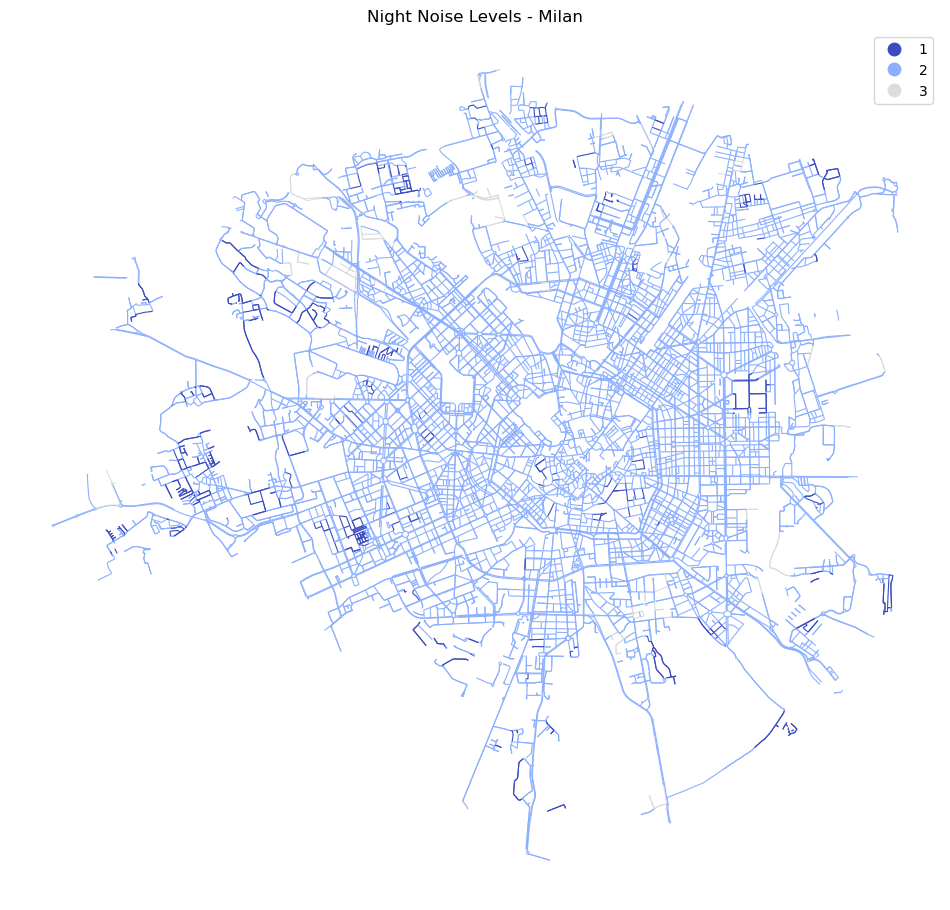

In [16]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_night', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Night Noise Levels - Milan')
ax.set_axis_off()

## Convert category to numerical feature

In [17]:
noise_roads['road_category'] = noise_roads['highway']
noise_roads['road_category'].value_counts()

road_category
residential      14146
tertiary          4345
secondary         2297
primary           1284
trunk               66
living_street       26
Name: count, dtype: int64

In [18]:
category_map = {
    'trunk': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'residential': 5,
    'living_street': 6
}

noise_roads['category_code'] = noise_roads['highway'].map(category_map)
noise_roads.head()

,osmid,highway,lanes,name,oneway,reversed,length,geometry,maxspeed,junction,...,is_tunnel,CLASSE_ACU,db_diurno,db_notturno,distance,noise_day,noise_evening,noise_night,road_category,category_code
0,274433644,primary,2,Via Novara,True,False,154.435012,"LINESTRING (505987.753 5037117.669, 505836.365...",NaN,NaN,...,0,4,65.0,55.0,0.0,3,3,2,primary,2
1,26703159,tertiary,NaN,Via Novara,True,False,150.466270,"LINESTRING (505987.753 5037117.669, 505947.376...",NaN,NaN,...,0,4,65.0,55.0,0.0,3,3,2,tertiary,4
2,"[270440428, 270390234, 270439972, 270390223]",primary,2,Via Novara,True,False,1075.839734,"LINESTRING (507976.056 5036258.912, 507948.227...",70,NaN,...,0,4,65.0,55.0,0.0,3,3,2,primary,2
3,195654896,secondary,2,Viale Certosa,False,False,41.927380,"LINESTRING (510208.477 5038452.225, 510173.072...",50,NaN,...,0,4,65.0,55.0,0.0,3,3,2,secondary,3
4,195654901,secondary,NaN,Viale Certosa,True,False,16.212785,"LINESTRING (510208.477 5038452.225, 510208.318...",NaN,NaN,...,0,4,65.0,55.0,0.0,3,3,2,secondary,3


## Calculate distance to the closest road of each category

In [19]:
# Ensure unique index and keep a stable row id for repeated nearest joins
noise_roads = noise_roads.reset_index(drop=True).copy()
noise_roads['road_idx'] = noise_roads.index

# Drop join helper columns if they exist to avoid conflicts in repeated runs
join_helper_cols = ['index_right'] + [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads = noise_roads.drop(columns=[col for col in join_helper_cols if col in noise_roads.columns], errors='ignore')

road_categories = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street']

for category in road_categories:
    category_roads = noise_roads[noise_roads['highway'] == category][['geometry']].copy()
    distance_col = f'dist_to_{category}'

    if category_roads.empty:
        noise_roads[distance_col] = pd.NA
        continue

    nearest_category = noise_roads[['road_idx', 'geometry']].sjoin_nearest(
        category_roads,
        how='left',
        distance_col=distance_col
    )
    min_distances = nearest_category.groupby('road_idx')[distance_col].min()
    noise_roads[distance_col] = noise_roads['road_idx'].map(min_distances)

noise_roads = noise_roads.drop(columns=['road_idx']).drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,lanes,name,oneway,reversed,length,geometry,maxspeed,junction,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,274433644,primary,2,Via Novara,True,False,154.435012,"LINESTRING (505987.753 5037117.669, 505836.365...",NaN,NaN,...,3,2,primary,2,1139.168597,0.000000,3243.971228,0.000000,295.923522,288.328932
1,26703159,tertiary,NaN,Via Novara,True,False,150.466270,"LINESTRING (505987.753 5037117.669, 505947.376...",NaN,NaN,...,3,2,tertiary,4,1106.773564,0.000000,3243.971228,0.000000,289.266957,266.547014
2,"[270440428, 270390234, 270439972, 270390223]",primary,2,Via Novara,True,False,1075.839734,"LINESTRING (507976.056 5036258.912, 507948.227...",70,NaN,...,3,2,primary,2,2119.581742,0.000000,1317.601503,79.177942,14.866980,1472.511721
3,195654896,secondary,2,Viale Certosa,False,False,41.927380,"LINESTRING (510208.477 5038452.225, 510173.072...",50,NaN,...,3,2,secondary,3,0.000000,436.049701,0.000000,194.533835,13.506098,2720.309808
4,195654901,secondary,NaN,Viale Certosa,True,False,16.212785,"LINESTRING (510208.477 5038452.225, 510208.318...",NaN,NaN,...,3,2,secondary,3,10.182633,436.049701,0.000000,194.533835,0.000000,2717.720476


In [20]:
# Summarize distance-to-category features
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads[distance_cols].describe()

,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
count,22164.000000,22164.000000,22164.000000,22164.000000,22164.000000,22164.000000
mean,2163.875109,731.931362,483.890009,186.857964,19.398489,2227.482243
std,1291.021445,664.294355,567.519928,213.236917,91.860091,1209.636908
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1120.936326,212.300166,64.792590,0.000000,0.000000,1349.693088
50%,2145.669960,558.827940,312.571470,127.837376,0.000000,2013.371949
75%,3027.463176,1060.602711,676.928420,295.954734,0.000000,3100.273771
max,6622.202419,4058.499553,4100.317455,1478.097297,1383.801701,5769.743480


## Calculate distance to major road

In [21]:
# Filter target roads
target_categories = ['trunk', 'primary', 'secondary' ]
target_roads = noise_roads[noise_roads['highway'].isin(target_categories)].copy()

# Ensure unique index
noise_roads = noise_roads.reset_index(drop=True)
target_roads = target_roads.reset_index(drop=True)

# Drop 'index_right' if it exists to avoid conflicts with sjoin_nearest
if 'index_right' in noise_roads.columns:
    noise_roads = noise_roads.drop(columns=['index_right'])

# Spatial join: each noise road gets its nearest target road (no duplication)
noise_roads = noise_roads.sjoin_nearest(
    target_roads[['geometry']], how='left', distance_col='dist_to_main'
)
noise_roads.fillna(0) #fillna(0) to replace any NaN values with 0
noise_roads = noise_roads.drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,lanes,name,oneway,reversed,length,geometry,maxspeed,junction,...,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,index_right,dist_to_main
0,274433644,primary,2,Via Novara,True,False,154.435012,"LINESTRING (505987.753 5037117.669, 505836.365...",NaN,NaN,...,primary,2,1139.168597,0.000000,3243.971228,0.000000,295.923522,288.328932,1529,0.0
1,26703159,tertiary,NaN,Via Novara,True,False,150.466270,"LINESTRING (505987.753 5037117.669, 505947.376...",NaN,NaN,...,tertiary,4,1106.773564,0.000000,3243.971228,0.000000,289.266957,266.547014,1529,0.0
2,"[270440428, 270390234, 270439972, 270390223]",primary,2,Via Novara,True,False,1075.839734,"LINESTRING (507976.056 5036258.912, 507948.227...",70,NaN,...,primary,2,2119.581742,0.000000,1317.601503,79.177942,14.866980,1472.511721,2174,0.0
3,195654896,secondary,2,Viale Certosa,False,False,41.927380,"LINESTRING (510208.477 5038452.225, 510173.072...",50,NaN,...,secondary,3,0.000000,436.049701,0.000000,194.533835,13.506098,2720.309808,1615,0.0
4,195654901,secondary,NaN,Viale Certosa,True,False,16.212785,"LINESTRING (510208.477 5038452.225, 510208.318...",NaN,NaN,...,secondary,3,10.182633,436.049701,0.000000,194.533835,0.000000,2717.720476,1877,0.0


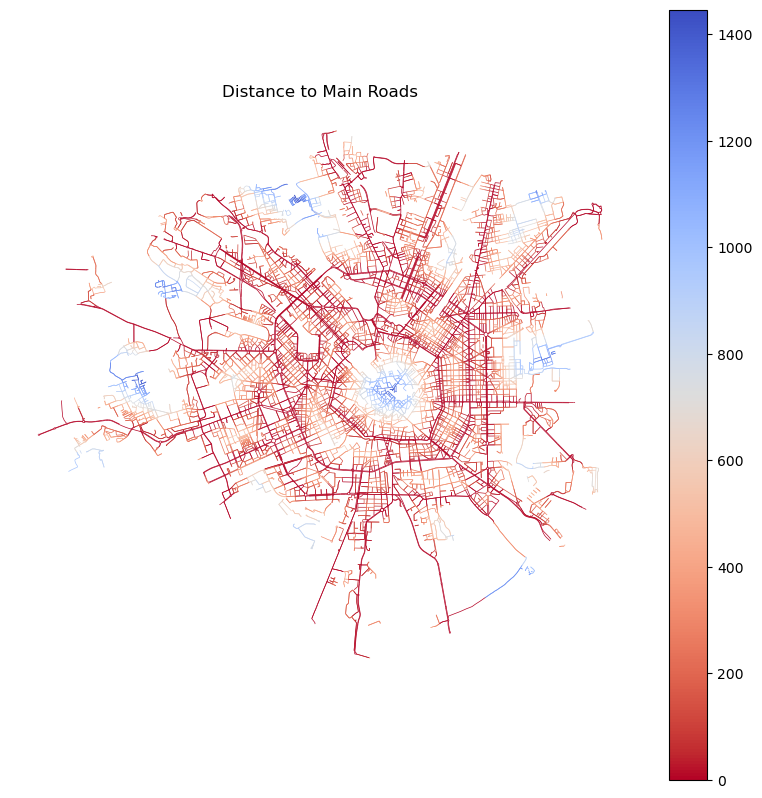

In [22]:
# Plot Distance to Main Roads
ax = noise_roads.plot(column='dist_to_main', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Distance to Main Roads')
ax.set_axis_off()

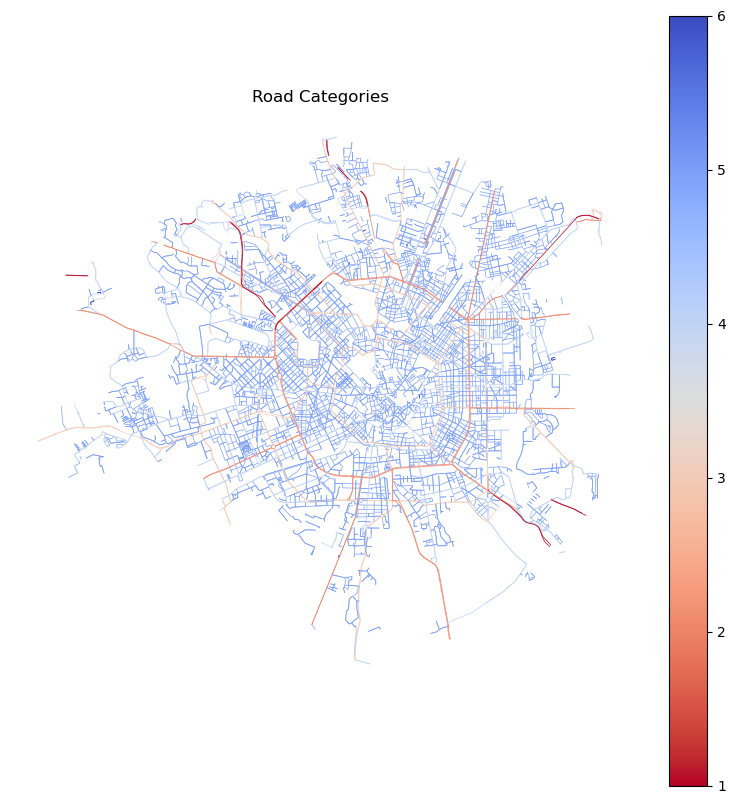

In [23]:
# Plot Road Categories
ax = noise_roads.plot(column='category_code', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Road Categories')
ax.set_axis_off()

In [24]:
noise_roads.head()

,osmid,highway,lanes,name,oneway,reversed,length,geometry,maxspeed,junction,...,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,index_right,dist_to_main
0,274433644,primary,2,Via Novara,True,False,154.435012,"LINESTRING (505987.753 5037117.669, 505836.365...",NaN,NaN,...,primary,2,1139.168597,0.000000,3243.971228,0.000000,295.923522,288.328932,1529,0.0
1,26703159,tertiary,NaN,Via Novara,True,False,150.466270,"LINESTRING (505987.753 5037117.669, 505947.376...",NaN,NaN,...,tertiary,4,1106.773564,0.000000,3243.971228,0.000000,289.266957,266.547014,1529,0.0
2,"[270440428, 270390234, 270439972, 270390223]",primary,2,Via Novara,True,False,1075.839734,"LINESTRING (507976.056 5036258.912, 507948.227...",70,NaN,...,primary,2,2119.581742,0.000000,1317.601503,79.177942,14.866980,1472.511721,2174,0.0
3,195654896,secondary,2,Viale Certosa,False,False,41.927380,"LINESTRING (510208.477 5038452.225, 510173.072...",50,NaN,...,secondary,3,0.000000,436.049701,0.000000,194.533835,13.506098,2720.309808,1615,0.0
4,195654901,secondary,NaN,Viale Certosa,True,False,16.212785,"LINESTRING (510208.477 5038452.225, 510208.318...",NaN,NaN,...,secondary,3,10.182633,436.049701,0.000000,194.533835,0.000000,2717.720476,1877,0.0


## Export Milan noise streets layer

MIL_noise_streets.gpkg (layer `noise_streets`) in `deployment/Milan/layers/` — all filtered
street segments with segment_id, highway, name, length, acoustic class, dB limits and
noise classes. This is the street layer consumed by the momepy / points / landuse notebooks.

In [25]:
export_cols = ['segment_id', 'highway', 'name', 'length',
               'CLASSE_ACU', 'db_diurno', 'db_notturno',
               'noise_day', 'noise_evening', 'noise_night', 'distance', 'geometry']
export_gdf = noise_roads[[c for c in export_cols if c in noise_roads.columns]].copy()
export_gdf['name'] = export_gdf['name'].astype(str)
export_gdf['noise_day'] = export_gdf['noise_day'].astype(int)

out_gpkg = os.path.join(_layers_dir, 'MIL_noise_streets.gpkg')
export_gdf.to_file(out_gpkg, layer='noise_streets', driver='GPKG')
print('Exported:', out_gpkg)
print('Segments:', len(export_gdf))

C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Cannot find tms_NZTM2000.json (GDAL_DATA is not defined)
  ogr_write(


Exported: C:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Milan\layers\MIL_noise_streets.gpkg
Segments: 22164


## Create data frame

In [26]:
dataset = pd.DataFrame({
    "road_id": noise_roads['segment_id'],
    "noise_day": noise_roads['noise_day'].astype(int),
    "noise_evening": noise_roads['noise_evening'],
    "noise_night": noise_roads['noise_night'],
    "road_category": noise_roads['category_code'],
    **{f'dist_to_{c}': noise_roads[f'dist_to_{c}'] for c in road_categories},
}).fillna(0)

dataset = dataset.drop_duplicates(subset='road_id', keep='first')
dataset.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,10371529_743371634_0,3,3,2,2,1139.168597,0.000000,3243.971228,0.000000,295.923522,288.328932
1,10371529_743371622_0,3,3,2,4,1106.773564,0.000000,3243.971228,0.000000,289.266957,266.547014
2,10371530_267873043_0,3,3,2,2,2119.581742,0.000000,1317.601503,79.177942,14.866980,1472.511721
3,13595397_271096577_0,3,3,2,3,0.000000,436.049701,0.000000,194.533835,13.506098,2720.309808
4,13595397_344814479_0,3,3,2,3,10.182633,436.049701,0.000000,194.533835,0.000000,2717.720476


## Check correlation with noise

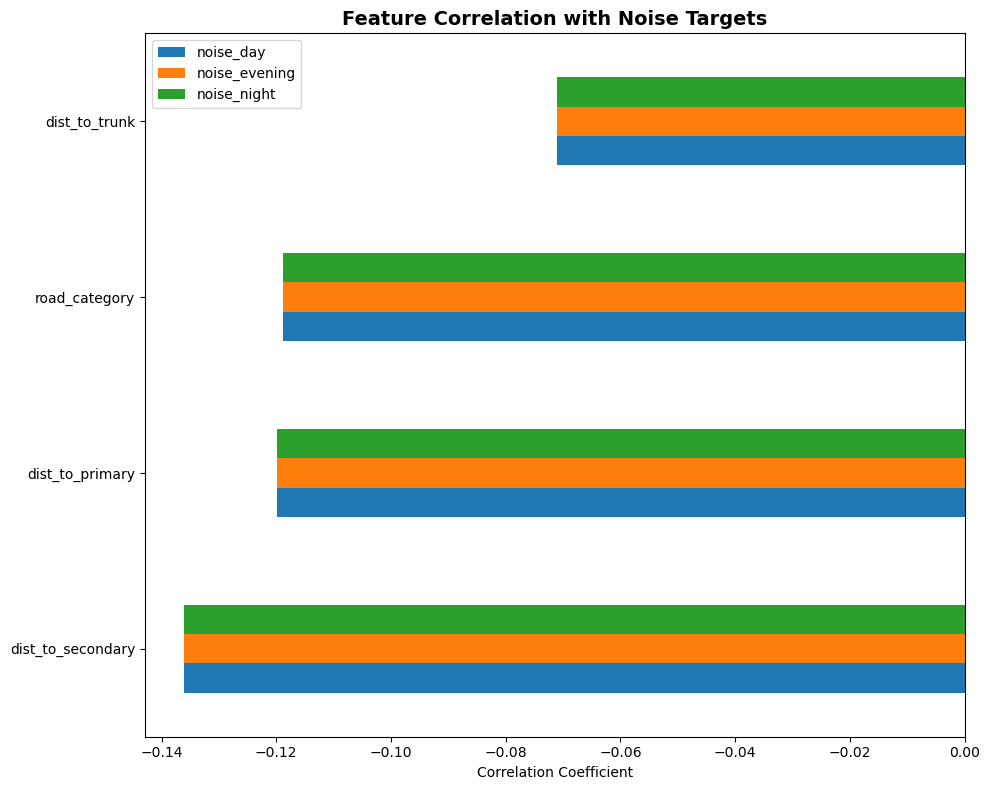

                   noise_day  noise_evening  noise_night
dist_to_trunk      -0.071039      -0.071039    -0.071039
road_category      -0.118734      -0.118734    -0.118734
dist_to_primary    -0.119913      -0.119913    -0.119913
dist_to_secondary  -0.136060      -0.136060    -0.136060


In [27]:
# Extract correlations with noise predictions
dataset_filtered = dataset[['noise_day', 'noise_evening', 'noise_night', 'road_category',
                            'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary']]
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

## Export dataset to CSV

In [28]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_roads_noise_class.csv"), index=False)
print("Exported osm_roads_noise_class.csv")

Exported osm_roads_noise_class.csv
